In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='tenure'>

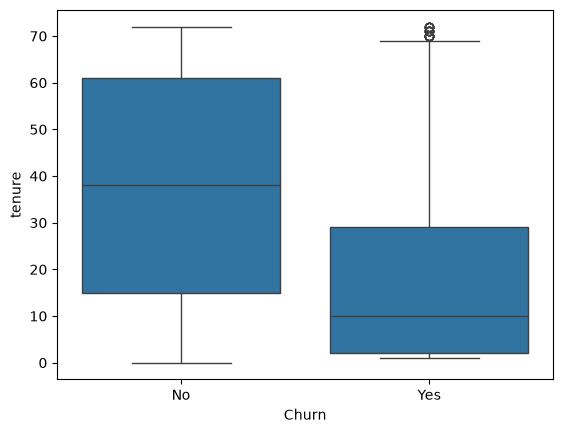

In [7]:
sns.boxplot(data=df, x='Churn', y='tenure')

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

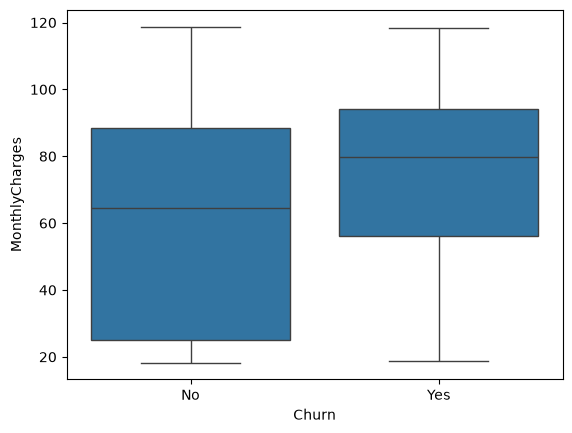

In [8]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

<Axes: xlabel='Contract', ylabel='count'>

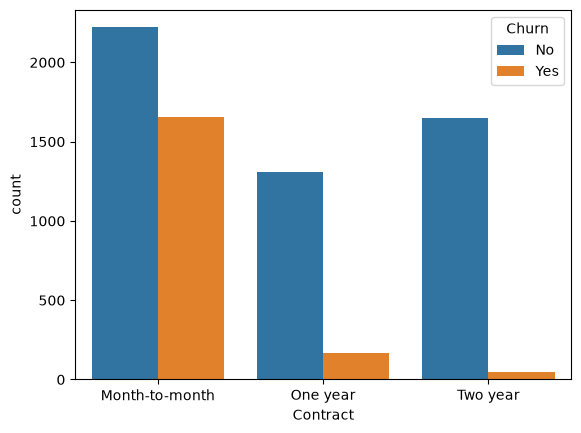

In [9]:
sns.countplot(data=df, x='Contract', hue='Churn') 

In [10]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [12]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [13]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [14]:
df.drop(columns='customerID', inplace = True)

In [15]:
df['Churn']=df['Churn'].map({'No':0, 'Yes':1})

In [16]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'] 
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1}) 
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']: 
    df[col] = df[col].map({'No': 0, 'Yes': 1}) 

In [17]:
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                   'Contract', 'PaymentMethod'] 
  
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True) 
df = df.astype({col: int for col in df.select_dtypes('bool').columns}) 

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X=df.drop(columns='Churn')
y=df['Churn']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
numeric_cols=['tenure', 'MonthlyCharges','TotalCharges']
scaler=StandardScaler()
X_train[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [21]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000, class_weight='balanced')

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score

In [23]:
models={
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'KNear Neighbor': KNeighborsClassifier(n_neighbors=9),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'SVM': SVC(random_state=42, class_weight='balanced', probability=True)
}

In [24]:
result=[]

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    result.append({
        'Model':name,
        'Accuracy Score': round(accuracy_score(y_test,y_pred),4),
        'precision Score':round(precision_score(y_test,y_pred),4),
        'Recall Score': round(recall_score(y_test,y_pred),4),
        'f1_score': round(f1_score(y_test,y_pred),4)
    })

In [25]:
result_df=pd.DataFrame(result).sort_values(by='Recall Score', ascending=False)
result_df

,Model,Accuracy Score,precision Score,Recall Score,f1_score
0,Logistic Regression,0.7388,0.5052,0.7834,0.6143
4,SVM,0.7466,0.5150,0.7807,0.6206
3,Random Forest,0.7686,0.5553,0.6444,0.5965
1,KNear Neighbor,0.7736,0.5745,0.5668,0.5707
2,Decision Tree,0.7253,0.4823,0.4733,0.4777


              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



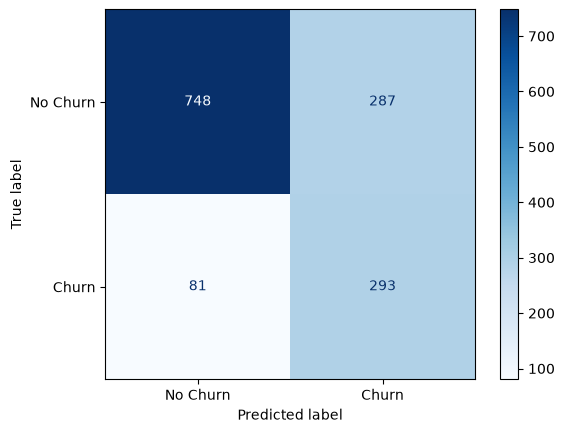

In [28]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay 
best_model=models['Logistic Regression']
y_pred=best_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues') 
print(classification_report(y_test,y_pred))

In [30]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'penalty':['l1','l2'],
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear']
}

grid=GridSearchCV(best_model, param_grid,cv=5,scoring='recall', n_jobs=-1)
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [31]:
print(grid.best_params_)

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [32]:
final_model=grid.best_estimator_

In [34]:
y_pred=final_model.predict(X_test)

In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [37]:
import joblib 
joblib.dump(final_model, 'churn_model.pkl') 
joblib.dump(scaler, 'churn_scaler.pkl') 
joblib.dump(numeric_cols, 'churn_numeric_cols.pkl') 
joblib.dump(X.columns.tolist(), 'churn_columns.pkl') 

['churn_columns.pkl']

In [40]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')